In [1]:
import numpy as np
import matplotlib.pyplot as plt

## CREATE SYNTHETIC DATA TO TEST

Text(0.5, 1.0, 'Ground truth Y data')

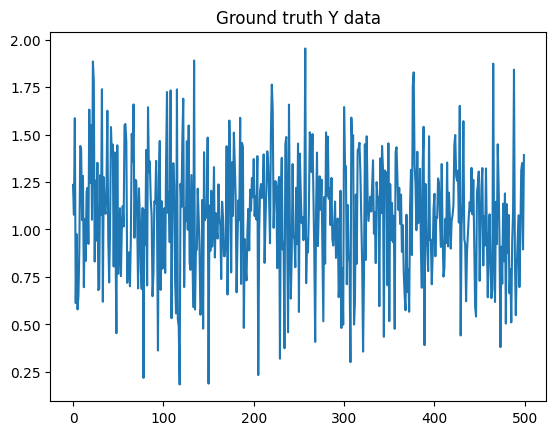

In [2]:
rng = np.random.default_rng(seed=0)
N = 500
D = 2

means = rng.uniform(low=0, high=5, size=2)
variance = np.array([1] * D)
X = rng.normal(loc=means, scale=variance, size=(N, 2))
W = rng.normal(size=(D, 1))
C = rng.uniform(size=1)
Y =  X @ W + C # ground truth

# Plot the data
plt.plot(Y)
plt.title("Ground truth Y data")


## Test-Train split

In [6]:
data = np.hstack([X, Y])
rng.shuffle(data)

X_train, X_test = data[:400, :2], data[400:, :2]
Y_train, Y_test = data[:400, 2], data[400:, 2]

print("Train shapes: ", X_train.shape, Y_train.shape)
print("Test shapes: ", X_test.shape, Y_test.shape)

Train shapes:  (400, 2) (400,)
Test shapes:  (100, 2) (100,)


# Using Numpy (Batch Gradient Descent)

## Train the Linear Regression Model

In [7]:
Epochs = 100
learning_rate = 0.01
# training using batch GD
W = rng.normal(size=(D, 1)) * 0.01
B = rng.normal(size=1) * 0.01
Y_train_ = Y_train.reshape(-1, 1)
print(X_train.shape, W.shape)

for _ in range(Epochs):
    # forward pass
    Yhat = X_train @ W  + B
    # backward pass

    # compute error
    error = (Yhat - Y_train_) / X_train.shape[0] # (N, 1)
    error_grad = X_train.T @ error # (D, 1)
    # update weights
    W -= learning_rate * error_grad
    B -= learning_rate * error.sum(axis=0)



(400, 2) (2, 1)


RMSE 0.07530356950866088


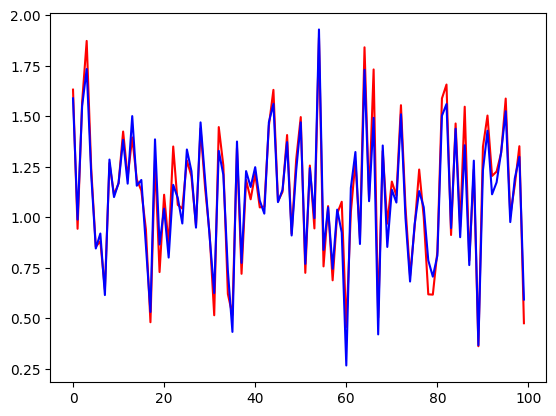

In [8]:
# X_test_ = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
Ypred = X_test @ W + B

# plot the results
plt.plot(Y_test, color="r")
plt.plot(Ypred, color="b")

# compute rmse
se = (Ypred - Y_test.reshape(-1, 1)) ** 2
print("RMSE", se.mean() ** 0.5)

# Using PyTorch (Batch Gradient Descent)

In [9]:
import torch 
import torch.nn.functional as F

In [10]:
torch.manual_seed(0)
D = 2

W = torch.randn(size=(D,1), dtype=torch.float32) * 0.01
B = torch.randn((), dtype=torch.float32) * 0.01
X_train_ = torch.tensor(X_train, dtype=torch.float32)
Y_train_ = torch.tensor(Y_train, dtype=torch.float32).reshape(-1, 1)

epochs = 100
for _ in range(epochs):
    yhat = X_train_ @ W + B # N, 1
    error = (yhat - Y_train_) / X_train_.shape[0]
    grad = X_train_.T @ error

    W -= learning_rate * grad
    B -= learning_rate * error.sum()



RMSE: tensor(0.0696)


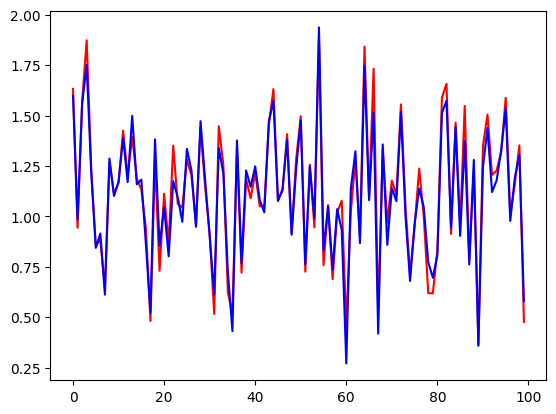

In [11]:
# plot & see results
Ypred = torch.tensor(X_test, dtype=torch.float32) @ W + B

plt.plot(Y_test, color="r")
plt.plot(Ypred, color="b")

mse = (Ypred - torch.tensor(Y_test,dtype=torch.float32).reshape(-1, 1)) ** 2
print("RMSE:", mse.mean() ** 0.5)

# Mini-Batch Gradient Descent (Numpy)

In [18]:
epochs = 100
batch_size = 1
num_iterations = X_train.shape[0] // batch_size

X_train_ = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
W = rng.normal(size=(D + 1, 1)) * 0.01
Y_train_ = Y_train.reshape(-1, 1)

for _ in range(epochs):
    for i in range(num_iterations + 1):
        start = i * batch_size
        end = min(start + batch_size, X_train.shape[0])

        X, Y = X_train_[start:end], Y_train_[start:end]

        #forward prop
        yhat = X @ W 

        # Backprop
        error = (yhat - Y) / X.shape[0]
        grad = X.T @ error
        W -= learning_rate * grad

RMSE 1.0540104466658658e-15


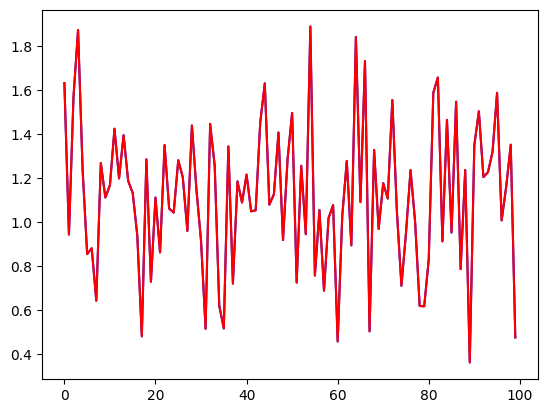

In [19]:
Ypred = np.hstack([np.ones((X_test.shape[0], 1)), X_test]) @ W 
plt.plot(Y_test, color="b")
plt.plot(Ypred, color="r")

# compute rmse
se = (Ypred - Y_test.reshape(-1, 1)) ** 2
print("RMSE", se.mean() ** 0.5)

# Mini-Batch Gradient Descent (PyTorch)

In [30]:
from typing import Any

epochs = 100
batch_size = 256
num_iters = X_train.shape[0] // batch_size
learning_rate = 0.01

X_train_ = torch.tensor(X_train, dtype=torch.float32)
Y_train_ = torch.tensor(Y_train, dtype=torch.float32).reshape(-1, 1)
W = torch.randn(size=(2, 1), dtype=torch.float32) * 0.01
B = torch.randn((), dtype=torch.float32) * 0.01

for _ in range(epochs):
    for i in range(num_iters + 1):
        start = i * batch_size
        end = min(start + batch_size, X_train_.shape[0])

        X, Y = X_train_[start:end], Y_train_[start:end]
        # forward pass
        yhat = X @ W + B

        # backprop
        error = (yhat - Y) / X.shape[0]
        grad = X.T @ error
        W -= learning_rate * grad
        B -= learning_rate * error.sum()



RMSE: tensor(0.0263, dtype=torch.float64)


/var/folders/ss/2wt5cscs613gxlzm9tzyrwvr0000gn/T/ipykernel_43120/1496398567.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  se = (Ypred - Y_test.reshape(-1, 1)) ** 2


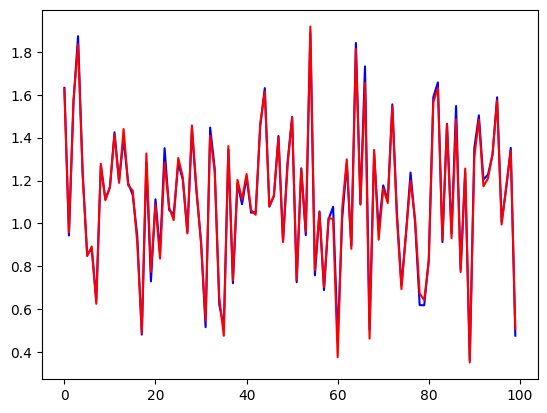

In [31]:
# plot
Ypred = torch.tensor(X_test, dtype=torch.float32) @ W + B

plt.plot(Y_test, color="b")
plt.plot(Ypred, color="r")

se = (Ypred - Y_test.reshape(-1, 1)) ** 2
print("RMSE:", se.mean() ** 0.5)
